# Testing

In [1]:
from lapsim.normalisation import TransformNormalisation
from lapsim.evals.evaluate import  evaluate, estimate_lap_time, calculate_optimal_positions, find_apexes
import webdataset as wd
from lapsim.models.lapsim import LapSimModel
import webdataset
from lapsim.preprocessor.encoder import decode
import json
import numpy as np
import mlflow
import torch
import os
import mlflow

FORESIGHT = 120
SAMPLING = 4
# NORMALISATION_BOUNDS_PATH = "bounds.json"
NORMALISATION_BOUNDS_PATH = "bounds-new.json"

DATESET = "/Users/belle/Developer/MlLapSim/dataset/spliced-again-10/lapsim-real-00.tar"

bounds = TransformNormalisation.load(NORMALISATION_BOUNDS_PATH)
bounds.transform.method = "flat-window"
bounds.transform.foresight = FORESIGHT
bounds.transform.sampling = SAMPLING

model = LapSimModel(
    "ls2.pt",
    bounds
)



In [2]:


model = LapSimModel(
    "ls2.pt",
    bounds
)

os.environ["MLFLOW_TRACKING_URI"] = "http://192.168.0.180:5000"
model.model = mlflow.pytorch.load_model(
    "mlflow-artifacts:/1/models/m-b97f7f4faaac4b7daa80bcc0625b83a6/artifacts", 
    map_location=model.device
)

dataset = webdataset.WebDataset(DATESET)\
    .map(decode)



2026/06/19 21:24:07 WARNING mlflow.pytorch: Stored model version '2.10.0+cu130' does not match installed PyTorch version '2.10.0'
/Users/belle/Developer/MlLapSim/venv/lib/python3.14/site-packages/webdataset/compat.py:379: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn("WebDataset(shardshuffle=...) is None; set explicitly to False or a number")


In [3]:
# Run predictions
requests = list(dataset)
predictions = model.predict(requests)
pairs = list(zip(requests, predictions))

Donea Mx5 Mk3 - US Las Vegas Motor Speedway - Outfield North Road Course                                                                                    


In [4]:


errors = evaluate(pairs)

for key, value in errors.items():
    if "sorted" in key: 
        continue
        
    print(key, value)

laptime/mean 0.11545801
laptime/mean-abs 1.0102484
laptime/rmse 1.4422101
laptime/percentile-25 0.31822968
laptime/percentile-50 0.7185669
laptime/percentile-75 1.3641815
laptime/percentile-95 2.960228
laptime/max 12.996681
laptime-per-kilometer/mean 0.025701256
laptime-per-kilometer/mean-abs 0.3598036
laptime-per-kilometer/rmse 0.77848506
laptime-per-kilometer/percentile-25 0.09335109
laptime-per-kilometer/percentile-50 0.20786688
laptime-per-kilometer/percentile-75 0.3993178
laptime-per-kilometer/percentile-95 1.0409976
laptime-per-kilometer/max 17.68668
position/mean -0.074209735
position/mean-abs 0.6882255
position/rmse 1.2007738
position/percentile-25 0.1141698
position/percentile-50 0.34507787
position/percentile-75 0.84489286
position/percentile-95 2.5647783
position/max 20.724813
position/apex/mean 0.062435072
position/apex/mean-abs 0.31835523
position/apex/rmse 0.80192274
position/apex/percentile-25 0.021695573
position/apex/percentile-50 0.08475834
position/apex/percentile-75

(np.float32(65.83795), {'__key__': 'test/Generic Lola T70 Mk3B - US Willow Springs International Raceway - Streets of Willow Springs Medium Course with Chicane', '__url__': '/Users/belle/Developer/MlLapSim/dataset/spliced-again-10/lapsim-real-00.tar', 'acc': array([-15.160019  , -16.161884  , -16.3273    , -16.187904  ,
       -16.065586  , -15.919727  , -15.856001  , -15.686373  ,
       -15.4279375 , -14.881551  , -14.349379  ,  -7.735921  ,
        -2.3831782 ,  -1.5939832 ,   2.9923651 ,   5.6726103 ,
         3.5959144 ,  -4.299274  ,  -2.0147393 ,  -1.7114402 ,
         4.1785345 ,  11.530715  ,   0.75026196,  -1.3373044 ,
         1.3355836 ,   4.093487  ,   4.8586783 ,  -9.794482  ,
        -6.268137  ,  -2.15472   ,  -1.7030394 ,   2.9864464 ,
         5.636767  ,  -7.468088  ,  -3.0439737 ,  -1.9043751 ,
         4.026686  ,  10.949606  ,   9.481215  ,   2.123164  ,
        -1.463138  ,  -0.2028965 ,   8.2882    ,  -1.7615122 ,
        -1.4514537 ,  -1.5234733 ,  -0.4882024 ,

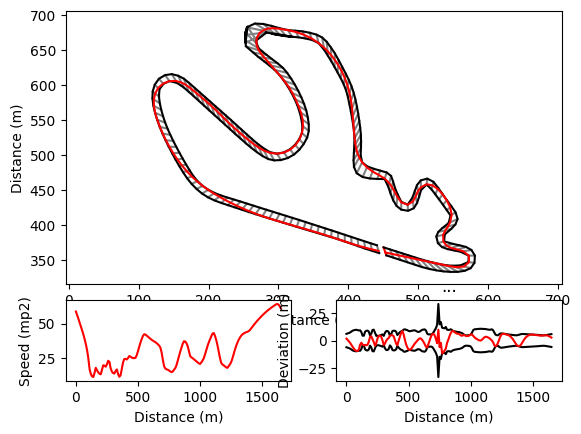

In [12]:

largest = 0, None

for track in dataset:
    track_max_width = np.max(track["widths"])
    if track_max_width > largest[0]:
        largest = track_max_width, track

from toolkit import maths


from lapsim.render import plot_full, RenderItem

print(largest)

plot_full(
    tracks=[
        RenderItem(
            track=largest[1],
            label="Predicted",
            color="red"
        ),
    ],
    title="..."
)

In [6]:
import lapsim.render

In [7]:
dir(lapsim.render.plot_full)

['__annotate__',
 '__annotations__',
 '__builtins__',
 '__call__',
 '__class__',
 '__closure__',
 '__code__',
 '__defaults__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__get__',
 '__getattribute__',
 '__getstate__',
 '__globals__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__kwdefaults__',
 '__le__',
 '__lt__',
 '__module__',
 '__name__',
 '__ne__',
 '__new__',
 '__qualname__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__type_params__']

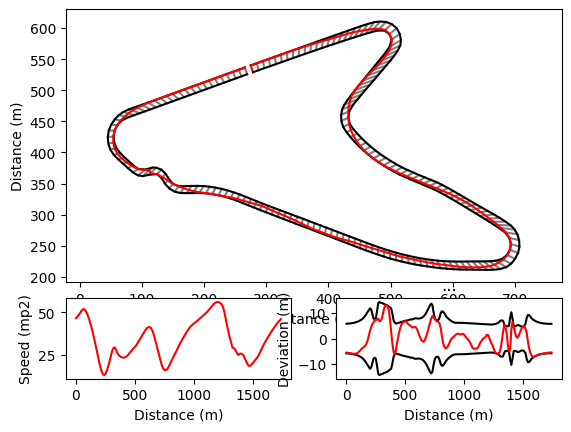

In [8]:



# todo check the widths
# todo scan data to make sure no crosses


plot_full(
    tracks=[
        RenderItem(
            track=pairs[0][1],
            label="Predicted",
            color="red"
        ),
    ],
    title="..."
)



In [21]:
TRAIN_DATASET = "/Users/belle/Developer/MlLapSim/dataset/spliced-again-10/lapsim-train-{00..04}.tar"
VALIDATION_DATASET = "/Users/belle/Developer/MlLapSim/dataset/spliced-again-10/lapsim-validation-00.tar"
TEST_DATASET = "/Users/belle/Developer/MlLapSim/dataset/spliced-again-10/lapsim-test-00.tar"
REAL_DATASET = "/Users/belle/Developer/MlLapSim/dataset/spliced-again-10/lapsim-real-00.tar"


dataset = webdataset.WebDataset(REAL_DATASET)\
    .map(decode)

items = []
for record in dataset:
    if "F1" not in record["__key__"]: continue
    # print(record["__key__"])
    # break
    items.append((record, np.max(record["widths"])))

# rank items by how bad the widths are
items = sorted(items, key=lambda x: x[1], reverse=True)
items = [x[0] for x in items]


F1 - US Willow Springs International Raceway - Streets of Willow Springs Medium Course with Chicane


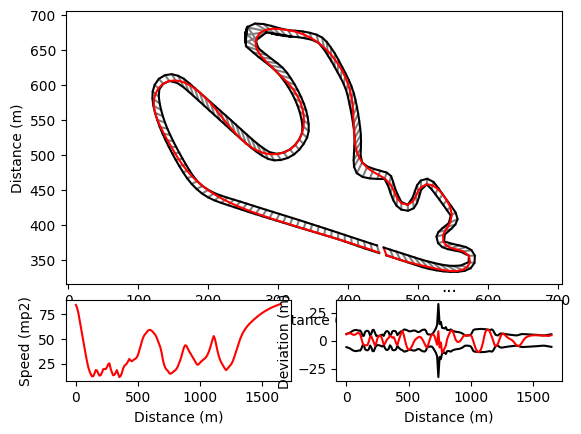

Generic 1982 Ground Effect F1 - US Willow Springs International Raceway - Streets of Willow Springs Medium Course with Chicane


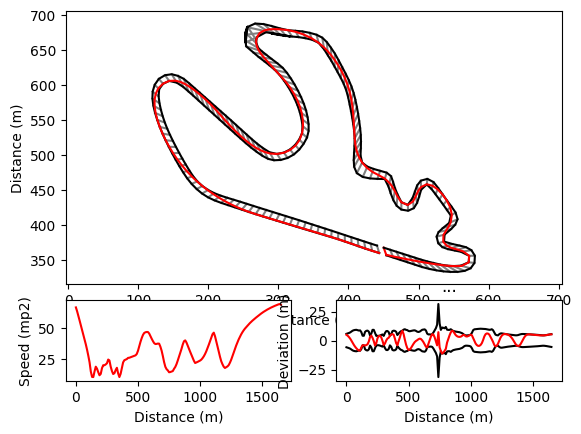

F1 - US Circuit of the Americas - National Circuit


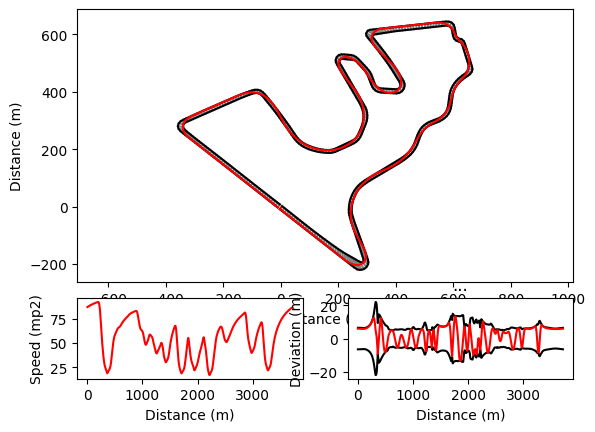

F1 - US Circuit of the Americas - Grand Prix Circuit


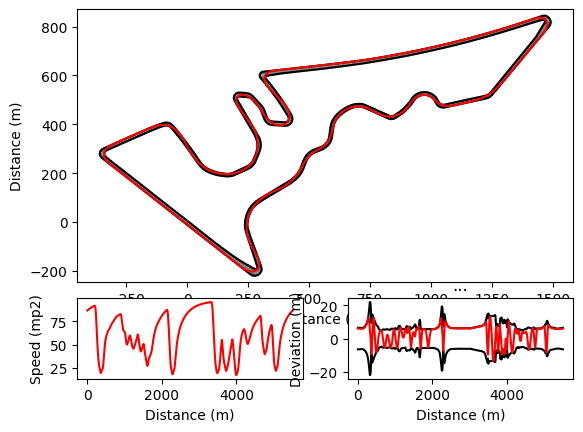

Generic 1982 Ground Effect F1 - US Circuit of the Americas - National Circuit


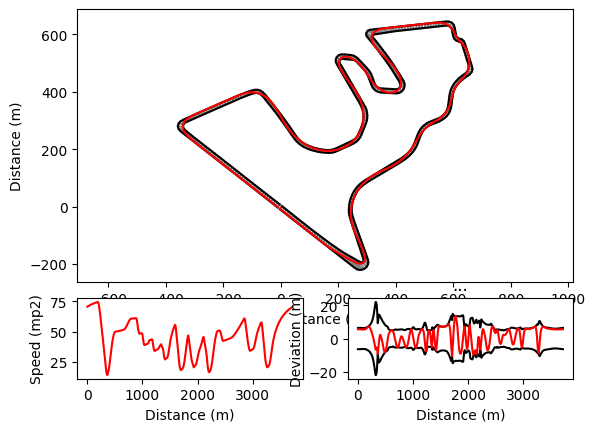

Generic 1982 Ground Effect F1 - US Circuit of the Americas - Grand Prix Circuit


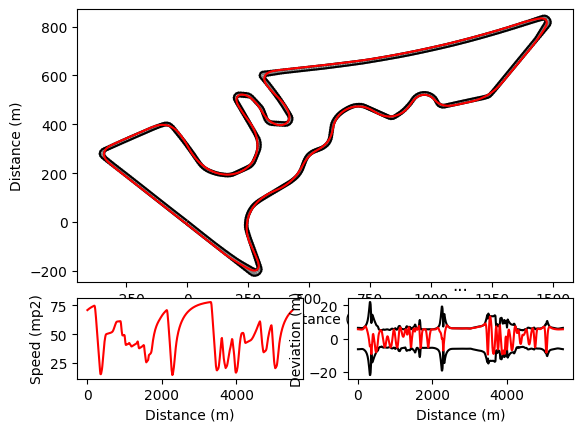

F1 - AR Parque La Pedrera - Autodromo Jose Carlos Bassi


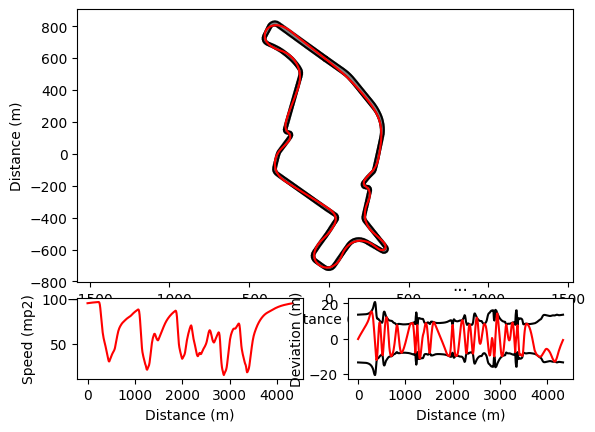

Generic 1982 Ground Effect F1 - AR Parque La Pedrera - Autodromo Jose Carlos Bassi


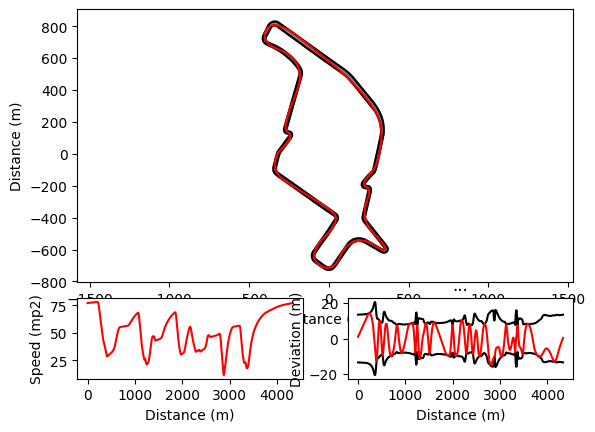

F1 - IN Buddh International Circuit - Short Circuit 1


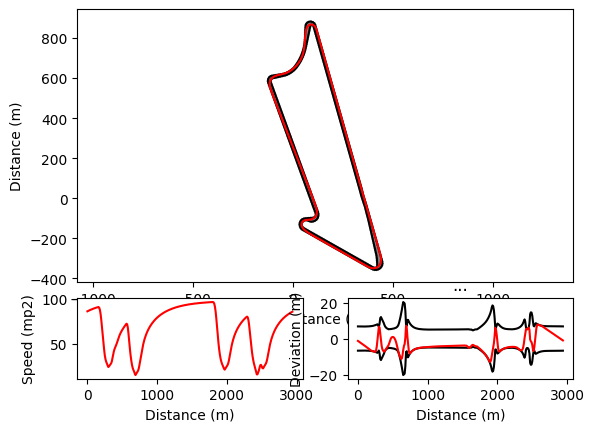

Generic 1982 Ground Effect F1 - IN Buddh International Circuit - Short Circuit 1


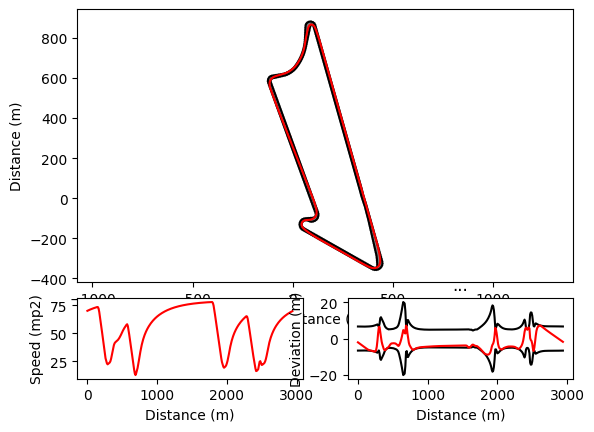

In [22]:
from lapsim.render import RenderItem, plot_full

for i, record in enumerate(items[:10]):
    print(record["id"])
    plot_full(
        tracks=[
            RenderItem(
                track=record,
                label="Predicted",
                color="red"
            ),
        ],
        title="..."
    )


In [11]:
eval_pairs = [x for x in pairs if x[0]["id"] in best_tracks]

NameError: name 'best_tracks' is not defined

In [ ]:
from lapsim.render import RenderItem, plot_full

for i, (input_record, output_record) in enumerate(eval_pairs):
    print(input_record["id"])
    plot_full(
        tracks=[
            RenderItem(
                track=output_record,
                label="Predicted",
                color="red"
            ),
            RenderItem(
                track=input_record,
                label="Ground Truth",
                color="green"
            ),
        ],
        title="..."
    )


In [ ]:
from lapsim.evals.evaluation import Evaluation
import pandas as pd

# import pandas as pd
# from neural_simulator_toolkit.lapsim.models.evaluation import Evaluation

# filter out none apex errors as they currently result in an issue
evaluatable_comparisons = [x for x in evaluations if x.position.apex_mean is not None]

combined = Evaluation.combine(evaluatable_comparisons)

combined.print_string()

print()


B## Combine Results
This combines results together based on track/vehicle results

In [ ]:
errors_by_track = {}
errors_by_vehicle = {}

for key, value, _, _ in evaluations:
    tokens = key.split(" - ")
    vehicle, track = tokens[0], " - ".join(tokens[1:])
    
    if track not in errors_by_track:
        errors_by_track[track] = []
    if vehicle not in errors_by_vehicle:
        errors_by_vehicle[vehicle] = []

    if value.position.apex_mean is not None:
        errors_by_track[track].append(value)
        errors_by_vehicle[vehicle].append(value)

for key in errors_by_vehicle:
    errors_by_vehicle[key] = Evaluation.combine(errors_by_vehicle[key])
for key in errors_by_track:
    errors_by_track[key] = Evaluation.combine(errors_by_track[key])


In [ ]:
def errors_to_df(errors):
    keys = list(errors)

    return pd.DataFrame({
        "Type": keys,
        "LapTime Error": [errors[x].laptime.abs_error for x in keys],
        "LapTime Percentage": [errors[x].laptime.percentage for x in keys],
        "LapTime Error Per Minute": [errors[x].laptime.error_per_minute for x in keys],

        "Position Error": [errors[x].position.mean_absolute for x in keys],
        "Position ci95": [errors[x].position.ci95 for x in keys],

        "Velocity Error": [errors[x].velocity.mean_absolute for x in keys],
        "Velocity ci95": [errors[x].velocity.ci95 for x in keys]
    })

vehicles_df = errors_to_df(errors_by_vehicle)
track_df = errors_to_df(errors_by_track)


In [ ]:
track_df